<a href="https://colab.research.google.com/github/IvanBaroni/projects-in-data/blob/main/IGN_Games_Exploratory_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IGN Games - Exploratory Analysis.
*by  Ivan Baroni*

For practice purposes, let's assume IGN has reviewed every game ever released for the platforms listed here, and all the data is included in this dataset from Kaggle.

**QUESTIONS**

1. What is the average score by **Platform**?

2. What is the average score by **Manufacturer**?

3. What is the average score by **Genre**?

4. What are the main differences between games that are **editors choice**?

5. What game **genres** are getting more popular with time?

6. How long has each **platform** had games released?

7. What **time of the year** do we have more game launches?

8. What are the 3 best games by **Platform**?

9. What is the best and the worst game for each **Genre**?

10. What are the words most often used on **Game Titles**?



# Importing the Dataset

In [1]:
#Libraries

# Data manipulation basics
import pandas as pd # Used for data manipulation and analysis
import numpy as np # Used for numerical operations
import statsmodels.api as sm # Used for statistical modeling

# Data Viz
import matplotlib.pyplot as plt # Used for creating static, animated, and interactive visualizations
import seaborn as sns # Used for making statistical graphics
import plotly.express as px # Used for creating interactive plots
import plotly.graph_objects as go # Used for creating custom interactive plots

# Google Docs importing
import io # Used for handling I/O operations
import requests # Used for making HTTP requests

# Word count / Word Cloud
!pip install wordcloud  > /dev/null
from wordcloud import WordCloud # Used for creating word clouds
from collections import Counter # Used for counting hashable objects
import re # Used for regular expression operations
import os # Used for interacting with the operating system
import nltk # Used for natural language processing
from nltk.corpus import stopwords # Used for filtering out stop words

# ydata profiling
!pip install ydata-profiling > /dev/null
from ydata_profiling import ProfileReport # Used for generating profile reports from a pandas DataFrame

In [2]:
#Libraries

# Data manipulation basics
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Data Viz
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Google Docs importing
import io
import requests

# Word count / Word Cloud
!pip install wordcloud  > /dev/null
from wordcloud import WordCloud
from collections import Counter
import re
import os
import nltk
from nltk.corpus import stopwords

# ydata profiling
!pip install ydata-profiling > /dev/null
from ydata_profiling import ProfileReport

In [3]:
#Import Dataset

url = "https://raw.githubusercontent.com/TheSarang/IGN-20-years-of-Games-Analysis/master/ign.csv"
response = requests.get(url)
df = pd.read_csv(io.StringIO(response.text))

df.head()

,Unnamed: 0,score_phrase,title,url,platform,score,genre,editors_choice,release_year,release_month,release_day
0,0,Amazing,LittleBigPlanet PS Vita,/games/littlebigplanet-vita/vita-98907,PlayStation Vita,9.0,Platformer,Y,2012,9,12
1,1,Amazing,LittleBigPlanet PS Vita -- Marvel Super Hero E...,/games/littlebigplanet-ps-vita-marvel-super-he...,PlayStation Vita,9.0,Platformer,Y,2012,9,12
2,2,Great,Splice: Tree of Life,/games/splice/ipad-141070,iPad,8.5,Puzzle,N,2012,9,12
3,3,Great,NHL 13,/games/nhl-13/xbox-360-128182,Xbox 360,8.5,Sports,N,2012,9,11
4,4,Great,NHL 13,/games/nhl-13/ps3-128181,PlayStation 3,8.5,Sports,N,2012,9,11


In [4]:
df_summary = pd.DataFrame({
    'Null Count': df.isnull().sum(),
    'Unique Count': df.nunique(),
    'Type': df.dtypes
    })

df_summary

,Null Count,Unique Count,Type
Unnamed: 0,0,18625,int64
score_phrase,0,11,object
title,0,12589,object
url,0,18577,object
platform,0,59,object
score,0,93,float64
genre,36,112,object
editors_choice,0,2,object
release_year,0,22,int64
release_month,0,12,int64


In [5]:
# correct a faulty register

# Rename the "Unnamed: 0" column to "id"
df = df.rename(columns={'Unnamed: 0': 'id'})

# Change the release date for the row with id == 516
df.loc[df['id'] == 516, ['release_year', 'release_month', 'release_day']] = [2012, 4, 24]

# Display the updated row to confirm the change
display(df[df['id'] == 516])

,id,score_phrase,title,url,platform,score,genre,editors_choice,release_year,release_month,release_day
516,516,Great,The Walking Dead: The Game -- Episode 1: A New...,/games/the-walking-dead-season-1-episode-1/xbo...,Xbox 360,8.5,Adventure,N,2012,4,24


In [6]:
profile = ProfileReport(df, title="Profiling Report")
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 11/11 [00:01<00:00,  8.88it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

# 1) What is the average score by **Platform**?

In [7]:
# @title ...
avg_score_by_platform = df.groupby('platform')['score'].mean().round(3).reset_index()
platform_counts = df['platform'].value_counts().reset_index()

platform_counts.columns = ['platform', 'count']

platform_analysis = pd.merge(avg_score_by_platform, platform_counts, on='platform')
platform_analysis

,platform,score,count
0,Android,7.546,39
1,Arcade,6.036,11
2,Atari 2600,5.900,5
3,Atari 5200,8.000,2
4,Commodore 64/128,6.417,6
5,DVD / HD Video Game,1.000,1
6,Dreamcast,7.370,286
7,Dreamcast VMU,3.000,1
8,Game Boy,7.814,22
9,Game Boy Advance,6.627,623


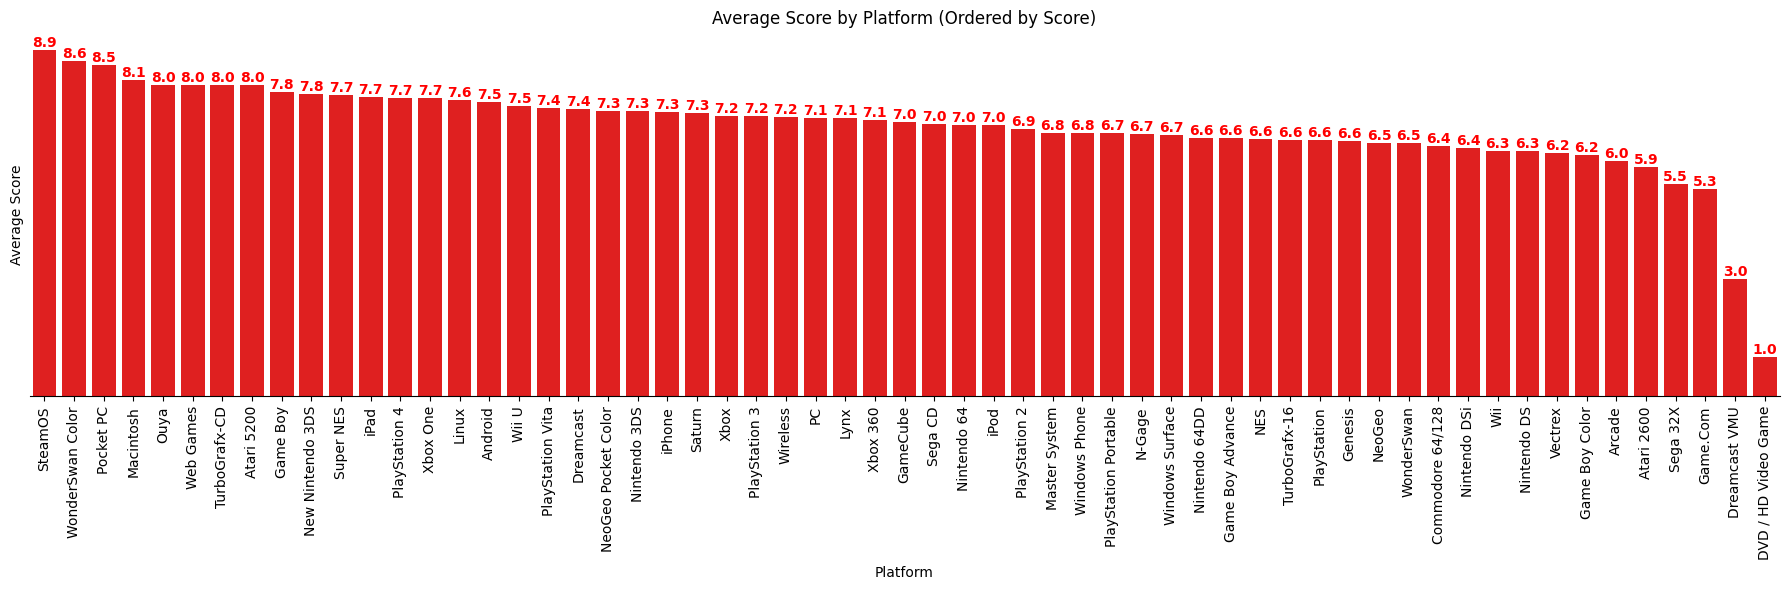

In [8]:
# @title ...
# Order by score
platform_analysis_sorted = platform_analysis.sort_values(by='score', ascending=False)

# Plotting
plt.figure(figsize=(18, 6))
ax = sns.barplot(x='platform', y='score', data=platform_analysis_sorted, color='red')
plt.xticks(rotation=90)
plt.title('Average Score by Platform (Ordered by Score)')
plt.xlabel('Platform')
plt.ylabel('Average Score')

# Add score numbers on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', label_type='edge', color='red',  weight='bold')

# Visual details
ax.set_yticks([]) # Hide y-axis labels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

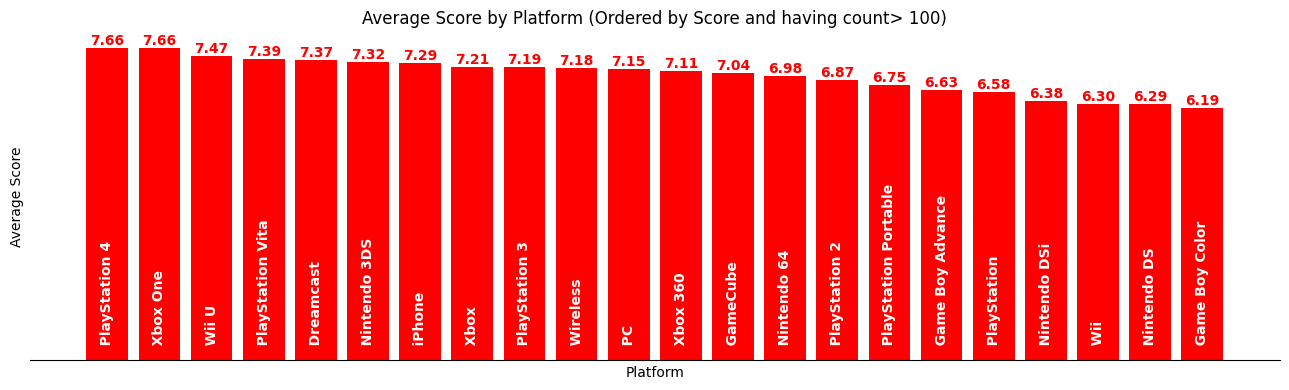

In [9]:
# @title ...
# Filter by count
platform_analysis_filtered = platform_analysis[platform_analysis['count'] > 100]
platform_analysis_filtered

# Order by score
platform_analysis_sorted = platform_analysis_filtered.sort_values(by='score', ascending=False)

# Plotting with matplotlib only
plt.figure(figsize=(13, 4))
ax = plt.bar(platform_analysis_sorted['platform'], platform_analysis_sorted['score'], color='red')

plt.title('Average Score by Platform (Ordered by Score and having count> 100)')
plt.xlabel('Platform')
plt.ylabel('Average Score')
plt.xticks(rotation=90)

# Add score numbers on top of bars and platform names inside bars at the base
for i, (platform, score) in enumerate(zip(platform_analysis_sorted['platform'], platform_analysis_sorted['score'])):
    # Add score numbers on top of bars
    plt.text(i, score, f'{score:.2f}', ha='center', va='bottom', color='red', weight='bold')
    # Add platform names inside bars at the base
    plt.text(i, 0, "   "+platform, ha='center', va='bottom', color='white',  weight='bold', rotation=90, fontsize=10)

# Visual details
ax = plt.gca() # Get the current axes
ax.set_yticks([]) # Hide y-axis labels
ax.set_xticks([]) # Hide y-axis labels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

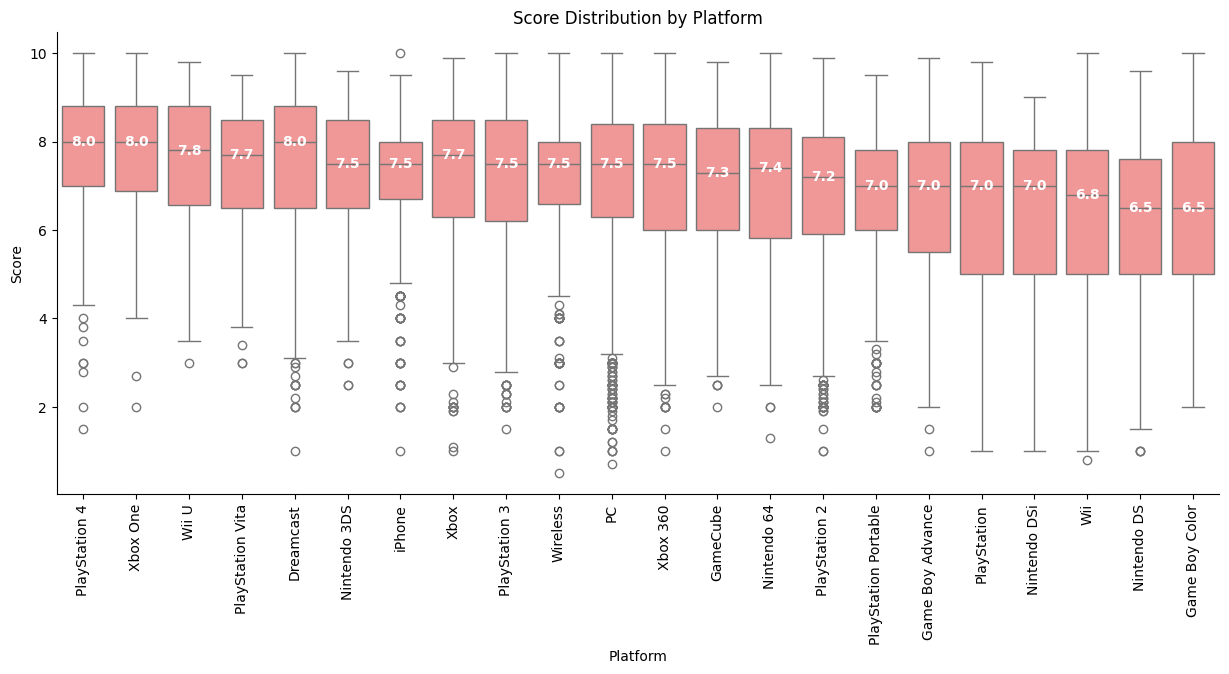

In [10]:
# @title ...
# Generate a boxplot for 'platform' using 'score'
plt.figure(figsize=(15, 6)) # Increased figure height to better accommodate min/max labels

# Calculate the average score for each platform and order the platforms by average score
platform_order = df[df['platform'].isin(platform_analysis_filtered['platform'])].groupby('platform')['score'].mean().sort_values(ascending=False).index

ax = sns.boxplot(x='platform', y='score', data=df[df['platform'].isin(platform_analysis_filtered['platform'])], color='#FF8888', order=platform_order)
plt.title('Score Distribution by Platform')
plt.xlabel('Platform')
plt.ylabel('Score')
plt.xticks(rotation=90)


# Add median labels to the boxplot
medians = df[df['platform'].isin(platform_analysis_filtered['platform'])].groupby(['platform'])['score'].median().reindex(platform_order)
for i, median in enumerate(medians):
    ax.text(i, median, f'{median:.1f}', ha='center', va='center', color='white', weight='bold')


# Make the square around the chart invisible
ax = plt.gca() # Get the current axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

# 2) What is the average score by **Manufacturer**?

In [11]:
# @title ...
sheet_url = "https://docs.google.com/spreadsheets/d/1O-7U1alPypICeYWkjbs0HwPODcqYaI2dS7IlJJNZyW8/edit?usp=sharing"
sheet_url = sheet_url.replace('/edit?usp=sharing', '/export?format=csv')

df_manufacturer = pd.read_csv(sheet_url)

# Merge the original dataframe with the manufacturer dataframe
df = pd.merge(df, df_manufacturer, left_on='platform', right_on='platform', how='left')

print(df[['platform', 'manufacturer']].head())

           platform manufacturer
0  PlayStation Vita         Sony
1  PlayStation Vita         Sony
2              iPad        Apple
3          Xbox 360    Microsoft
4     PlayStation 3         Sony


In [12]:
# @title ...
avg_score_by_manufacturer = df.groupby('manufacturer')['score'].mean().round(3).reset_index()
manufacturer_counts = df['manufacturer'].value_counts().reset_index()

manufacturer_counts.columns = ['manufacturer', 'count']

manufacturer_analysis = pd.merge(avg_score_by_manufacturer, manufacturer_counts, on='manufacturer')
manufacturer_analysis

,manufacturer,score,count
0,Apple,7.384,1039
1,Atari,7.084,89
2,Bandai,6.920,5
3,Google,7.546,39
4,Microsoft,7.177,2676
5,NEC,6.684,43
6,Nintendo,6.548,4907
7,Nokia,6.730,30
8,Other,7.148,4315
9,SNK,7.122,41


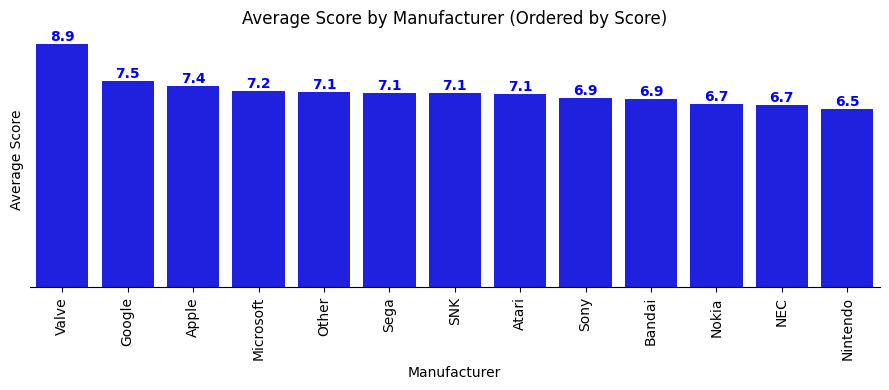

In [13]:
# @title ...
# Order by score
manufacturer_analysis_sorted = manufacturer_analysis.sort_values(by='score', ascending=False)

# Plotting
plt.figure(figsize=(9, 4))
ax = sns.barplot(x='manufacturer', y='score', data=manufacturer_analysis_sorted, color='blue')
plt.xticks(rotation=90)
plt.title('Average Score by Manufacturer (Ordered by Score)')
plt.xlabel('Manufacturer')
plt.ylabel('Average Score')

# Add score numbers on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', label_type='edge', color='blue',  weight='bold')

# Visual details
ax.set_yticks([]) # Hide y-axis labels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

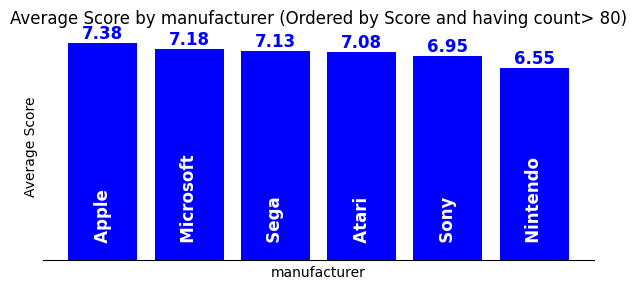

In [14]:
# @title ...
# Filter by count
manufacturer_analysis_filtered = manufacturer_analysis[manufacturer_analysis['count'] > 80]
manufacturer_analysis_filtered = manufacturer_analysis_filtered[manufacturer_analysis_filtered['manufacturer'] != 'Other']
manufacturer_analysis_filtered

# Order by score
manufacturer_analysis_sorted = manufacturer_analysis_filtered.sort_values(by='score', ascending=False)

# Plotting with matplotlib only
plt.figure(figsize=(6, 3))
ax = plt.bar(manufacturer_analysis_sorted['manufacturer'], manufacturer_analysis_sorted['score'], color='blue')

plt.title('Average Score by manufacturer (Ordered by Score and having count> 80)')
plt.xlabel('manufacturer')
plt.ylabel('Average Score')
plt.xticks(rotation=90)

# Add score numbers on top of bars and manufacturer names inside bars at the base
for i, (manufacturer, score) in enumerate(zip(manufacturer_analysis_sorted['manufacturer'], manufacturer_analysis_sorted['score'])):
    # Add score numbers on top of bars
    plt.text(i, score, f'{score:.2f}', ha='center', va='bottom', color='blue', weight='bold', fontsize=12)
    # Add manufacturer names inside bars at the base
    plt.text(i, 0, "   "+manufacturer, ha='center', va='bottom', color='white',  weight='bold', rotation=90, fontsize=12)

# Visual details
ax = plt.gca() # Get the current axes
ax.set_yticks([]) # Hide y-axis labels
ax.set_xticks([]) # Hide y-axis labels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

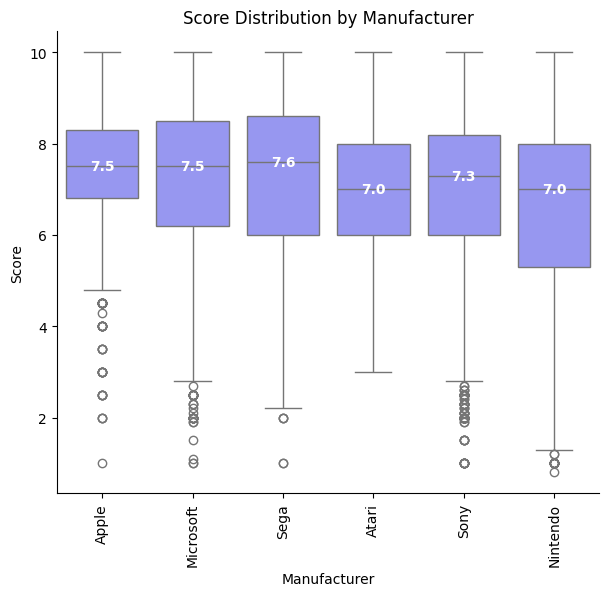

In [15]:
# @title ...
# Generate a boxplot for 'manufacturer' using 'score'
plt.figure(figsize=(7, 6)) # Increased figure height to better accommodate min/max labels

# Calculate the average score for each manufacturer and order them by average score
manufacturer_order = df[df['manufacturer'].isin(manufacturer_analysis_filtered['manufacturer'])].groupby('manufacturer')['score'].mean().sort_values(ascending=False).index

ax = sns.boxplot(x='manufacturer', y='score', data=df[df['manufacturer'].isin(manufacturer_analysis_filtered['manufacturer'])], color='#8888FF', order=manufacturer_order)
plt.title('Score Distribution by Manufacturer')
plt.xlabel('Manufacturer')
plt.ylabel('Score')
plt.xticks(rotation=90)


# Add median labels to the boxplot
medians = df[df['manufacturer'].isin(manufacturer_analysis_filtered['manufacturer'])].groupby(['manufacturer'])['score'].median().reindex(manufacturer_order)
for i, median in enumerate(medians):
    ax.text(i, median, f'{median:.1f}', ha='center', va='center', color='white', weight='bold')


# Make the square around the chart invisible
ax = plt.gca() # Get the current axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

# 3) What is the average score by **Genre**?

In [16]:
# @title ...
# Delete spaces from column genre
df['genre'] = df['genre'].str.replace(' ', '')

# create dummy variables for the 'genre' column, handling null values and splitting by comma
genre_dummies = df['genre'].str.get_dummies(sep=',')

# join the dummy variables to the original dataframe
df = df.join(genre_dummies)

In [17]:
pd.set_option('display.max_columns', None)
df.head()

,id,score_phrase,title,url,platform,score,genre,editors_choice,release_year,release_month,release_day,manufacturer,Action,Adult,Adventure,Baseball,Battle,Board,Card,Casino,Compilation,Editor,Educational,Episodic,Fighting,First-Person,Flight,Golf,Hardware,Hunting,Music,Other,Party,Pinball,Platformer,Productivity,Puzzle,RPG,Racing,Shooter,Simulation,Sports,Strategy,Trivia,VirtualPet,WordGame,Wrestling
0,0,Amazing,LittleBigPlanet PS Vita,/games/littlebigplanet-vita/vita-98907,PlayStation Vita,9.0,Platformer,Y,2012,9,12,Sony,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1,1,Amazing,LittleBigPlanet PS Vita -- Marvel Super Hero E...,/games/littlebigplanet-ps-vita-marvel-super-he...,PlayStation Vita,9.0,Platformer,Y,2012,9,12,Sony,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2,2,Great,Splice: Tree of Life,/games/splice/ipad-141070,iPad,8.5,Puzzle,N,2012,9,12,Apple,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
3,3,Great,NHL 13,/games/nhl-13/xbox-360-128182,Xbox 360,8.5,Sports,N,2012,9,11,Microsoft,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
4,4,Great,NHL 13,/games/nhl-13/ps3-128181,PlayStation 3,8.5,Sports,N,2012,9,11,Sony,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0


In [18]:
# @title ...
# Select only the genre dummy columns and the 'score' column
genre_columns = genre_dummies.columns

# Calculate the sum of scores for each genre by multiplying the dummy genre columns by the 'score' column
score_sum_by_genre = df[genre_columns].multiply(df['score'], axis=0).sum(axis=0)

# Calculate the count of games in each genre
genre_counts = df[genre_columns].sum(axis=0)

# Calculate the average score for each genre by dividing the sum of scores by the count
average_scores = score_sum_by_genre / genre_counts



In [19]:
# @title ...
# Convert the average_scores Series to a DataFrame
average_scores_df = average_scores.reset_index()
average_scores_df.columns = ['genre', 'average_score']

# Convert the genre_counts Series to a DataFrame
genre_counts_df = genre_counts.reset_index()
genre_counts_df.columns = ['genre', 'count']

# Merge the two DataFrames on the 'genre' column
genre_analysis = pd.merge(average_scores_df, genre_counts_df, on='genre')

# Display the combined DataFrame
display(genre_analysis.round(2))

,genre,average_score,count
0,Action,6.82,5894
1,Adult,5.40,3
2,Adventure,7.08,2032
3,Baseball,6.95,4
4,Battle,6.81,86
5,Board,6.61,123
6,Card,6.89,177
7,Casino,5.13,31
8,Compilation,6.98,215
9,Editor,7.35,13


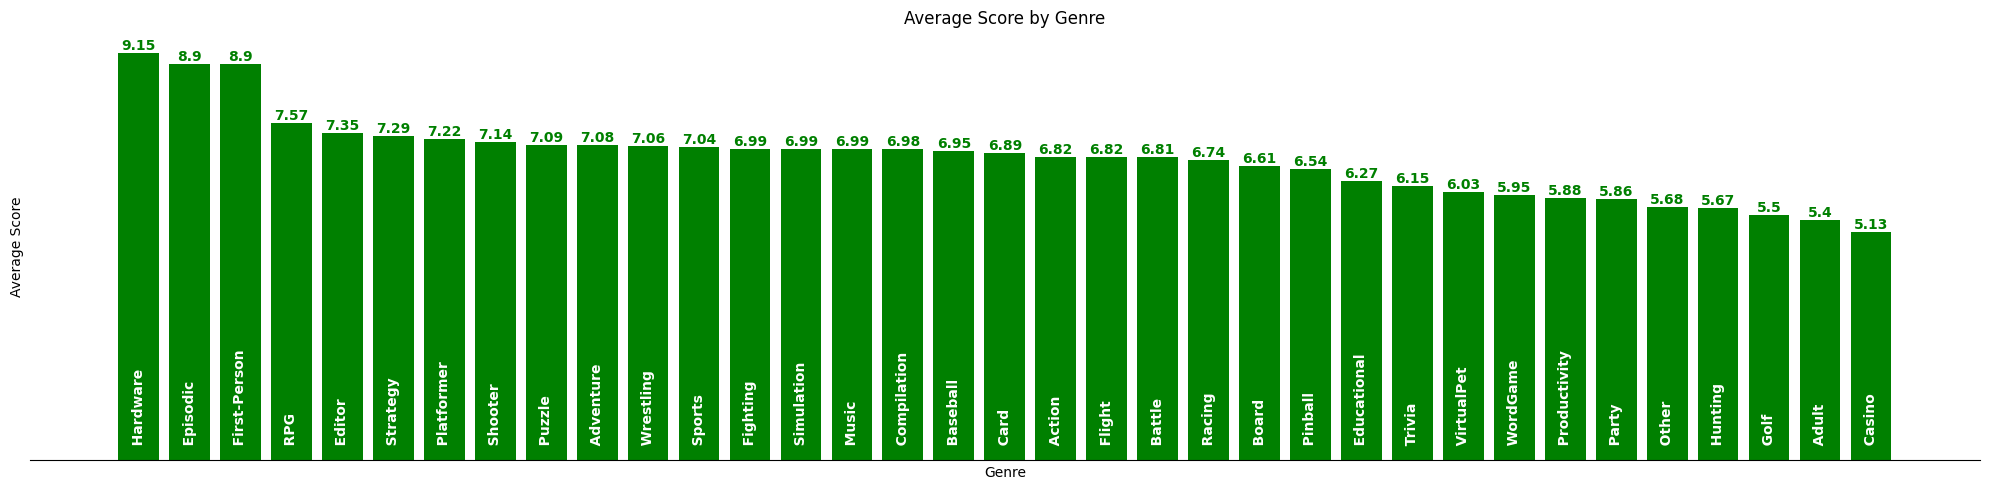

In [20]:
# @title ...
sorted_average_scores = average_scores.sort_values(ascending=False).round(2)

fig, ax = plt.subplots(figsize=(20, 5)) # Create figure and axes
bars = ax.bar(sorted_average_scores.index, sorted_average_scores.values, color='green')
ax.set_xlabel('Genre')
ax.set_ylabel('Average Score')
ax.set_title('Average Score by Genre')

ax.set_xticks([]) # Hide x-axis labels
ax.set_yticks([]) # Hide y-axis labels
ax.spines['top'].set_visible(False) # Hide the top spine
ax.spines['right'].set_visible(False) # Hide the right spine
ax.spines['left'].set_visible(False) # Hide the left spine


# Add numbers on top of the bars and rotated genre names inside the bars
for bar in bars:
    yval = bar.get_height()
    xval = bar.get_x()
    width = bar.get_width()
    genre_name = sorted_average_scores.index[list(bars).index(bar)]
    # Add number on top
    ax.text(xval + width/2., yval, round(yval, 2), ha='center', va='bottom', color='green', weight='bold')
    # Add rotated genre name inside, starting from the base and in bold
    ax.text(xval + width/2., 0, "   "+genre_name, ha='center', va='bottom', rotation=90, color='white', weight='bold')
plt.tight_layout()
plt.show()

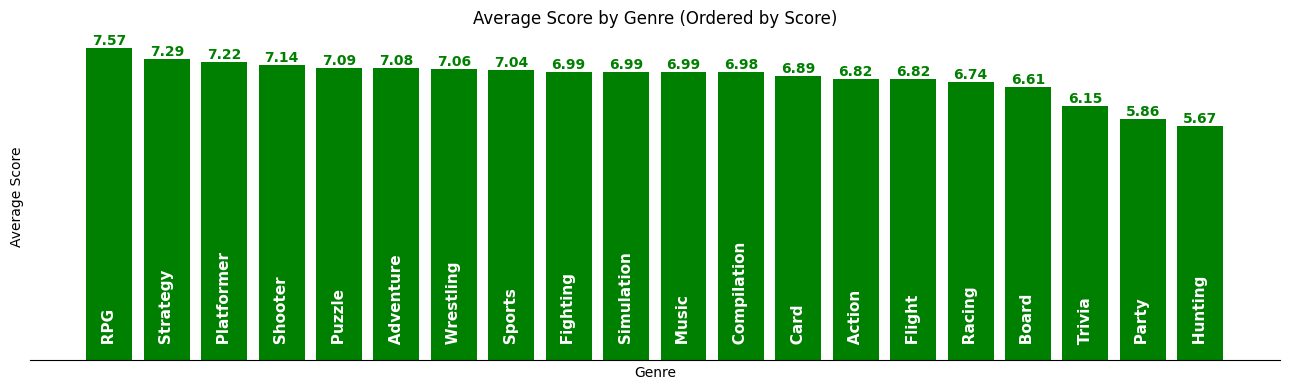

In [21]:
# @title ...
genre_analysis_filtered = genre_analysis[genre_analysis['count'] > 100]
genre_analysis_filtered

# Order by score
genre_analysis_sorted = genre_analysis_filtered.sort_values(by='average_score', ascending=False)

# Plotting with matplotlib only
plt.figure(figsize=(13, 4))
ax = plt.bar(genre_analysis_sorted['genre'], genre_analysis_sorted['average_score'], color='#008000')

plt.title('Average Score by Genre (Ordered by Score)')
plt.xlabel('Genre')
plt.ylabel('Average Score')
plt.xticks(rotation=90)

# Add average_score numbers on top of bars and genre names inside bars at the base
for i, (genre, average_score) in enumerate(zip(genre_analysis_sorted['genre'], genre_analysis_sorted['average_score'])):
    # Add average_score numbers on top of bars
    plt.text(i, average_score, f'{average_score:.2f}', ha='center', va='bottom', color='#008000', weight='bold')
    # Add genre names inside bars at the base
    plt.text(i, 0, "   "+genre, ha='center', va='bottom', color='white',  weight='bold', rotation=90, fontsize=11)

# Make the square around the chart invisible
ax = plt.gca() # Get the current axes
ax.set_yticks([]) # Hide y-axis labels
ax.set_xticks([]) # Hide y-axis labels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)


plt.tight_layout()
plt.show()


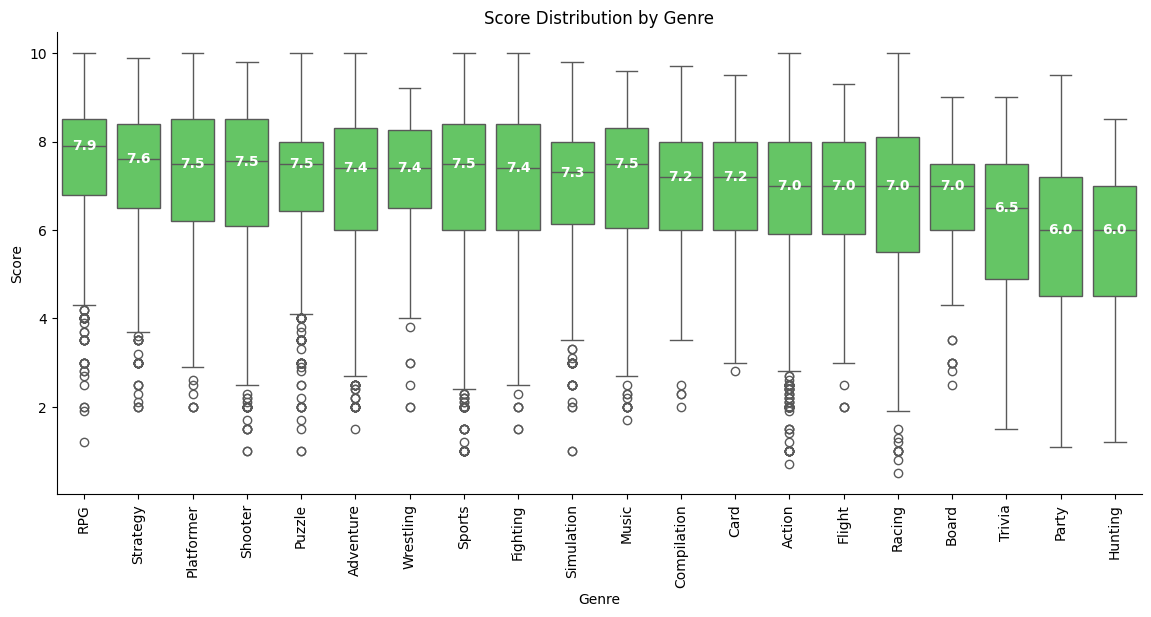

In [22]:
# @title ...
# Generate a boxplot for 'genre' using 'score'
plt.figure(figsize=(14, 6)) # Increased figure height to better accommodate min/max labels

# Calculate the average score for each genre and order them by average score
genre_order = genre_analysis_filtered.groupby('genre')['average_score'].mean().sort_values(ascending=False).index

# Unpivot the genre dummy columns to a long format
df_genres_long = df.melt(id_vars=['score'], value_vars=genre_dummies.columns, var_name='genre', value_name='is_genre')
df_genres_long = df_genres_long[df_genres_long['is_genre'] == 1]


ax = sns.boxplot(x='genre', y='score', data=df_genres_long[df_genres_long['genre'].isin(genre_analysis_filtered['genre'])], color='#55D555', order=genre_order)
plt.title('Score Distribution by Genre')
plt.xlabel('Genre')
plt.ylabel('Score')
plt.xticks(rotation=90)


# Add median labels to the boxplot
medians = df_genres_long[df_genres_long['genre'].isin(genre_analysis_filtered['genre'])].groupby(['genre'])['score'].median().reindex(genre_order)
for i, median in enumerate(medians):
    ax.text(i, median, f'{median:.1f}', ha='center', va='center', color='white', weight='bold')


# Make the square around the chart invisible
ax = plt.gca() # Get the current axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

# 4) What are the main differences between games that are **editors choice**?

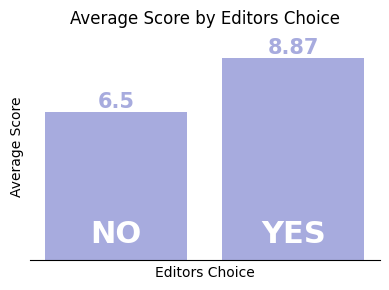

In [23]:
# @title ...
# Group by 'editors_choice' and calculate the average score
avg_score_by_editors_choice = df.groupby('editors_choice')['score'].mean().reset_index().round(2)

# Create a bar chart for average score by editors choice
plt.figure(figsize=(4, 3)) # Adjusted figure height slightly to better accommodate labels inside
ax = plt.bar(avg_score_by_editors_choice['editors_choice'], avg_score_by_editors_choice['score'], color='#A7ABDE') # Use light purple color

plt.title('Average Score by Editors Choice')
plt.xlabel('Editors Choice')
plt.ylabel('Average Score')
plt.ylim(0, 10) # Set y-axis limit to match score range

# Add average score values on top of the bars and labels inside the bars
for i, bar in enumerate(ax):
    yval = bar.get_height()
    xval = bar.get_x()
    width = bar.get_width()
    # Add average score on top
    plt.text(xval + width/2, yval, round(yval, 2), ha='center', va='bottom', color='#A7ABDE', weight='bold', fontsize=15)

    # Add label inside the bar
    label = avg_score_by_editors_choice['editors_choice'].iloc[i]
    display_label = 'NO' if label == 'N' else 'YES'
    plt.text(xval + width/2, 0.5, display_label, ha='center', va='bottom', color='white', weight='bold', fontsize=22) # Position label near the bottom

# Make the square around the chart invisible
ax = plt.gca() # Get the current axes
ax.set_yticks([]) # Hide y-axis labels
ax.set_xticks([]) # Hide y-axis labels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)


plt.tight_layout()
plt.show()

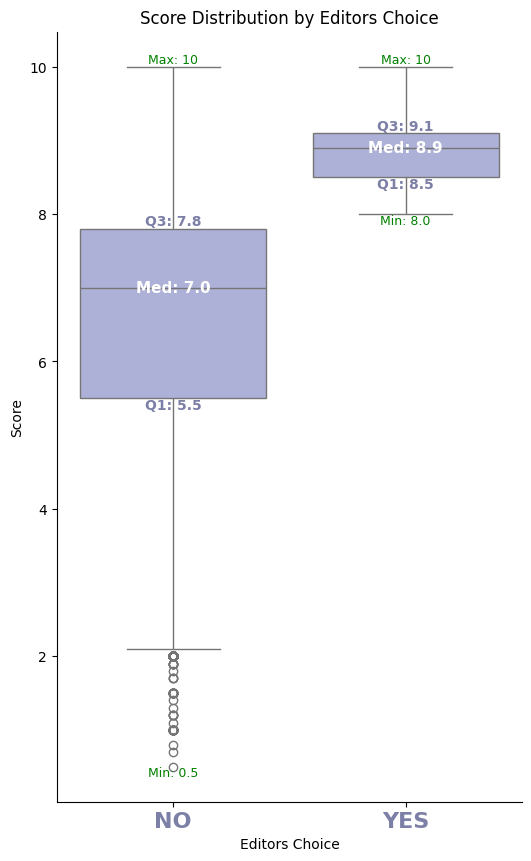

In [24]:
# @title ...
# Generate a boxplot for 'editors_choice' using 'score'
plt.figure(figsize=(6, 10)) # Increased figure height to better accommodate min/max labels
# Set the order of the boxes to 'N' then 'Y'
ax = sns.boxplot(x='editors_choice', y='score', data=df, color='#A7ABDE', order=['N', 'Y'])
plt.title('Score Distribution by Editors Choice')
plt.xlabel('Editors Choice')
plt.ylabel('Score')
# Set the x-axis labels to match the new order
plt.xticks([0, 1], ['NO', 'YES'], size='16', color='#7c7fa6', weight='bold' )

# Make the square around the chart invisible
ax = plt.gca() # Get the current axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Calculate quartiles, average, min, and max for each editors_choice group
quartiles_and_stats = df.groupby('editors_choice')['score'].agg(['min', 'max', 'median', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75), 'mean']).reset_index()
quartiles_and_stats.columns = ['editors_choice', 'min', 'max', 'median', 'q1', 'q3', 'mean']


# Add quartile, median, min, and max values to the boxplot
# Iterate in the order of the boxplot ('N' then 'Y')
for i, choice in enumerate(['N', 'Y']):
    row = quartiles_and_stats[quartiles_and_stats['editors_choice'] == choice].iloc[0]
    min_score = row['min']
    max_score = row['max']
    median_score = row['median']
    q1_score = row['q1']
    q3_score = row['q3']

    # Add median
    ax.text(i, median_score, f'Med: {median_score:.1f}', ha='center', va='center', color='white', fontsize=11, weight='bold')

    # Add Q1 (positioned at q1_score)
    ax.text(i, q1_score, f'Q1: {q1_score:.1f}', ha='center', va='top', color='#7c7fa6', fontsize=10, weight='bold')

    # Add Q3 (positioned at q3_score)
    ax.text(i, q3_score, f'Q3: {q3_score:.1f}', ha='center', va='bottom', color='#7c7fa6', fontsize=10, weight='bold')

    # Add Min (positioned below the lower whisker)
    ax.text(i, min_score, f'Min: {min_score:.1f}', ha='center', va='top', color='green', fontsize=9)

    # Add Max (positioned above the upper whisker)
    ax.text(i, max_score, f'Max: {max_score:.0f}', ha='center', va='bottom', color='green', fontsize=9)


plt.show()

In [25]:
# @title ...
# Group by score_phrase and calculate the average score and count
score_phrase_analysis = df.groupby('score_phrase')['score'].agg(['mean', 'count']).reset_index()

# Rename the columns for clarity
score_phrase_analysis.columns = ['score_phrase', 'average_score', 'count']

# Order the table by average score in descending order
score_phrase_analysis = score_phrase_analysis.sort_values(by='average_score', ascending=False)

# Format the 'average_score' column to 2 decimal places
score_phrase_analysis['average_score'] = score_phrase_analysis['average_score'].round(2)

# Display the table
display(score_phrase_analysis)

,score_phrase,average_score,count
6,Masterpiece,10.00,55
0,Amazing,9.18,1804
5,Great,8.32,4773
4,Good,7.37,4741
8,Okay,6.37,2945
7,Mediocre,5.32,1959
2,Bad,4.33,1269
1,Awful,3.29,664
9,Painful,2.27,340
10,Unbearable,1.29,72


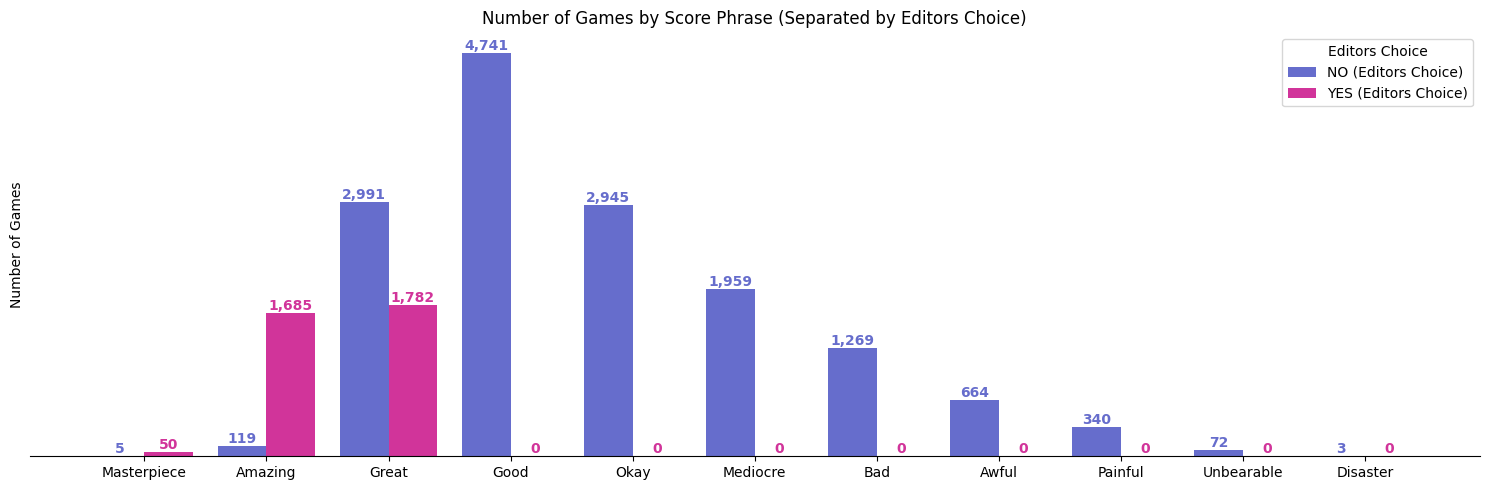

In [26]:
# @title ...
score_phrase_by_editors_choice = df.groupby(['editors_choice', 'score_phrase']).size().unstack(fill_value=0)


# Define the desired order of score phrases (reusing from cell CVBUZvSrr8l5)
score_phrase_order = ['Masterpiece', 'Amazing', 'Great', 'Good', 'Okay', 'Mediocre', 'Bad', 'Awful', 'Painful', 'Unbearable', 'Disaster']

# Filter the score_phrase_by_editors_choice DataFrame for 'editors_choice' = 'N' and 'Y'
score_phrase_counts_N = score_phrase_by_editors_choice.loc['N']
score_phrase_counts_Y = score_phrase_by_editors_choice.loc['Y']

# Convert the filtered Series to DataFrames and rename columns
score_phrase_counts_N_df = score_phrase_counts_N.reset_index()
score_phrase_counts_N_df.columns = ['score_phrase', 'count']
score_phrase_counts_Y_df = score_phrase_counts_Y.reset_index()
score_phrase_counts_Y_df.columns = ['score_phrase', 'count']

# Reindex the DataFrames to match the desired order
score_phrase_counts_N_ordered = score_phrase_counts_N_df.set_index('score_phrase').reindex(score_phrase_order).reset_index()
score_phrase_counts_Y_ordered = score_phrase_counts_Y_df.set_index('score_phrase').reindex(score_phrase_order).reset_index()

# Create a figure and axes
plt.figure(figsize=(15, 5)) # Increased figure width for side-by-side bars
ax = plt.gca()

bar_width = 0.40 # Width of each bar
x_positions = np.arange(len(score_phrase_order)) # Base x-positions for each score phrase

# Plot the bar chart for 'N' (shifted to the left) and store the bar objects
bars_N = ax.bar(x_positions - bar_width/2, score_phrase_counts_N_ordered['count'], bar_width, color='#666dcc', label='NO (Editors Choice)')

# Plot the bar chart for 'Y' (shifted to the right) and store the bar objects
bars_Y = ax.bar(x_positions + bar_width/2, score_phrase_counts_Y_ordered['count'], bar_width, color='#d1349a', label='YES (Editors Choice)')


plt.title('Number of Games by Score Phrase (Separated by Editors Choice)')
#plt.xlabel('Score Phrase')
plt.ylabel('Number of Games')
plt.xticks(x_positions, score_phrase_order, rotation=0, ha='center') # Set x-ticks at the center of the grouped bars
plt.legend(title='Editors Choice')

# Add count numbers on top of the 'N' bars with comma formatting
for bar in bars_N:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{int(yval):,}', ha='center', va='bottom', weight='bold', color='#666dcc') # Use f-string with comma

# Add count numbers on top of the 'Y' bars with comma formatting
for bar in bars_Y:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{int(yval):,}', ha='center', va='bottom', weight='bold', color='#d1349a') # Use f-string with comma


# Make the square around the chart invisible
ax = plt.gca() # Get the current axes
ax.set_yticks([]) # Hide y-axis labels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)


plt.tight_layout()
plt.show()

# 5) What game **genres** are getting more popular with time?

In [27]:
# @title ...
# Create a new column called "release_date"
# Temporarily rename columns for pd.to_datetime
temp_df = df[['release_year', 'release_month', 'release_day']].copy()
temp_df.columns = ['year', 'month', 'day']
df['release_date'] = pd.to_datetime(temp_df)

# Group by release_date and count the number of games
games_by_date = df.groupby('release_date').size().reset_index(name='game_count')

# Order the DataFrame by release_date
df_ordered_by_date = df.sort_values(by='release_date')

# Display the ordered DataFrame
display(df_ordered_by_date.head()) # Displaying head for brevity

,id,score_phrase,title,url,platform,score,genre,editors_choice,release_year,release_month,release_day,manufacturer,Action,Adult,Adventure,Baseball,Battle,Board,Card,Casino,Compilation,Editor,Educational,Episodic,Fighting,First-Person,Flight,Golf,Hardware,Hunting,Music,Other,Party,Pinball,Platformer,Productivity,Puzzle,RPG,Racing,Shooter,Simulation,Sports,Strategy,Trivia,VirtualPet,WordGame,Wrestling,release_date
515,515,Good,Baku Baku,/games/baku-baku/saturn-194,Saturn,7.0,Puzzle,N,1996,6,18,Sega,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1996-06-18
514,514,Amazing,Super Mario 64,/games/super-mario-64/n64-606,Nintendo 64,9.8,Platformer,Y,1996,9,25,Nintendo,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1996-09-25
488,488,Great,Pilotwings 64,/games/pilotwings-64/n64-83,Nintendo 64,8.2,Flight,N,1996,9,25,Nintendo,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1996-09-25
487,487,Mediocre,Batman Forever: The Arcade Game,/games/batman-forever/ps-318,PlayStation,5.0,Action,N,1996,11,2,Sony,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1996-11-02
486,486,Bad,Cruis'n USA,/games/cruisn-usa/n64-498,Nintendo 64,4.0,Racing,N,1996,11,14,Nintendo,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1996-11-14


In [28]:
# @title ...
# Create an interactive trendline chart with Plotly Express
fig = px.line(games_by_date, x='release_date', y='game_count',
              title='Number of Games Released per Day (Interactive)')

fig.update_xaxes(dtick="M12")

# Display the interactive plot
fig.show()

## Patform Evolution

In [29]:
# @title ...
# Group by platform and then resample the release_date to monthly frequency, summing the game counts
# Use 'on' parameter to specify the datetime column for resampling
games_by_month_platform = df.groupby('platform').resample('ME', on='release_date').size().reset_index(name='game_count')

# Get platforms with a total count greater than 100 (reusing platform_analysis)
platforms_to_keep = platform_analysis[platform_analysis['count'] > 100]['platform'].tolist()

# Filter the monthly game counts to include only the platforms to keep
games_by_month_platform_filtered = games_by_month_platform[games_by_month_platform['platform'].isin(platforms_to_keep)]


# Create an interactive trendline chart broken down by platform, using filtered monthly counts
fig = px.line(games_by_month_platform_filtered, x='release_date', y='game_count', color='platform',
              title='Number of Games Released per Month by Platform (Interactive, Count > 100)')

fig.update_xaxes(dtick="M12")

# Display the interactive plot
fig.show()

In [30]:
# @title ...
# Group by platform and then resample the release_date to yearly frequency, summing the game counts
# Use 'on' parameter to specify the datetime column for resampling
games_by_year_platform = df.groupby('platform').resample('YE', on='release_date').size().reset_index(name='game_count')

# Get platforms with a total count greater than 100 (reusing platform_analysis)
platforms_to_keep = platform_analysis[platform_analysis['count'] > 100]['platform'].tolist()

# Filter the yearly game counts to include only the platforms to keep
games_by_year_platform_filtered = games_by_year_platform[games_by_year_platform['platform'].isin(platforms_to_keep)]

# Create an interactive trendline chart broken down by platform, using filtered yearly counts
fig = px.line(games_by_year_platform_filtered, x='release_date', y='game_count', color='platform',
              title='Number of Games Released per Year by Platform (Interactive, Count > 100)')

fig.update_xaxes(dtick="M12")

# Display the interactive plot
fig.show()

## Manufacturer Evolution

In [31]:
# @title ...
# Group by manufacturer and then resample the release_date to monthly frequency, summing the game counts
# Use 'on' parameter to specify the datetime column for resampling
games_by_month_manufacturer = df.groupby('manufacturer').resample('ME', on='release_date').size().reset_index(name='game_count')

# Get manufacturers with a total count greater than 80 (reusing manufacturer_analysis)
manufacturers_to_keep = manufacturer_analysis[manufacturer_analysis['count'] > 80]['manufacturer'].tolist()

# Filter the monthly game counts to include only the manufacturers to keep
games_by_month_manufacturer_filtered = games_by_month_manufacturer[games_by_month_manufacturer['manufacturer'].isin(manufacturers_to_keep)]

# Create an interactive trendline chart broken down by manufacturer, using filtered monthly counts
fig = px.line(games_by_month_manufacturer_filtered, x='release_date', y='game_count', color='manufacturer',
              title='Number of Games Released per Month by Manufacturer (Interactive, Count > 80)')


fig.update_xaxes(dtick="M12")

# Display the interactive plot
fig.show()

In [32]:
# @title ...
# Group by manufacturer and then resample the release_date to yearly frequency, summing the game counts
# Use 'on' parameter to specify the datetime column for resampling
games_by_year_manufacturer = df.groupby('manufacturer').resample('YE', on='release_date').size().reset_index(name='game_count')

# Get manufacturers with a total count greater than 80 (reusing manufacturer_analysis)
manufacturers_to_keep = manufacturer_analysis[manufacturer_analysis['count'] > 80]['manufacturer'].tolist()

# Filter the yearly game counts to include only the manufacturers to keep
games_by_year_manufacturer_filtered = games_by_year_manufacturer[games_by_year_manufacturer['manufacturer'].isin(manufacturers_to_keep)]

# Create an interactive trendline chart broken down by manufacturer, using filtered yearly counts
fig = px.line(games_by_year_manufacturer_filtered, x='release_date', y='game_count', color='manufacturer',
              title='Number of Games Released per Year by Manufacturer (Interactive, Count > 80)')

fig.update_xaxes(dtick="M12")

# Display the interactive plot
fig.show()

## Genre Evolution

In [33]:
# @title ...
# Select release_date and the genre dummy columns
df_genres_time = df[['release_date'] + list(genre_dummies.columns)].copy()

# Melt the DataFrame to a long format
df_genres_time_melted = df_genres_time.melt(id_vars=['release_date'],
                                            var_name='genre',
                                            value_name='is_genre')

# Filter out rows where the game does not belong to the genre (is_genre == 0)
df_genres_time_filtered = df_genres_time_melted[df_genres_time_melted['is_genre'] == 1].drop('is_genre', axis=1)

# Group by genre and then resample the release_date to monthly frequency, summing the game counts
# Use 'on' parameter to specify the datetime column for resampling
games_by_month_genre = df_genres_time_filtered.groupby('genre').resample('ME', on='release_date').size().reset_index(name='game_count')


# Get genres with a total count greater than 100 (reusing genre_analysis)
genres_to_keep = genre_analysis[genre_analysis['count'] > 100]['genre'].tolist()

# Filter the monthly game counts to include only the genres to keep
games_by_month_genre_filtered = games_by_month_genre[games_by_month_genre['genre'].isin(genres_to_keep)]


# Create an interactive trendline chart broken down by genre, using filtered monthly counts
fig = px.line(games_by_month_genre_filtered, x='release_date', y='game_count', color='genre',
              title='Number of Games Released per Month by Genre (Interactive, Count > 100)')

fig.update_xaxes(dtick="M12")

# Display the interactive plot
fig.show()

In [34]:
# @title ...
# Use 'on' parameter to specify the datetime column for resampling
games_by_year_genre = df_genres_time_filtered.groupby('genre').resample('YE', on='release_date').size().reset_index(name='game_count')


# Get genres with a total count greater than 100 (reusing genre_analysis)
genres_to_keep = genre_analysis[genre_analysis['count'] > 100]['genre'].tolist()

# Filter the yearly game counts to include only the genres to keep
games_by_year_genre_filtered = games_by_year_genre[games_by_year_genre['genre'].isin(genres_to_keep)]


# Create an interactive trendline chart broken down by genre, using filtered yearly counts
fig = px.line(games_by_year_genre_filtered, x='release_date', y='game_count', color='genre',
              title='Number of Games Released per year by Genre (Interactive, Count > 100)')

fig.update_xaxes(dtick="M12")

# Display the interactive plot
fig.show()

## Game Quality Evolution

In [35]:
# @title ...
# Group by release_date and calculate the average score per day
average_score_by_date = df.groupby('release_date')['score'].mean().reset_index()

# Resample the daily average scores to monthly frequency and calculate the mean
average_score_by_month = average_score_by_date.set_index('release_date').resample('ME').mean().reset_index().dropna()

# Create an interactive line chart for average score by month using Plotly Express
fig = px.line(average_score_by_month, x='release_date', y='score',
              title='Average Game Score by Release Month (Interactive)')

# Add OLS trendline
X = sm.add_constant(average_score_by_month.index)
model = sm.OLS(average_score_by_month['score'], X)
results = model.fit()
fig.add_scatter(x=average_score_by_month['release_date'], y=results.predict(X), mode='lines', line=dict(dash='dash', width=2), name='Trendline')

# Add regression equation as annotation
equation = f'y = {results.params.iloc[1]:.3f}x + {results.params.iloc[0]:.3f}'
fig.add_annotation(x=average_score_by_month['release_date'].iloc[150], y=8, text=equation, showarrow=False, font=dict(color='red', weight='bold'))


fig.data[0].line.width = 4
fig.update_xaxes(dtick="M12")

# Display the interactive plot
fig.show()

In [36]:
# @title ...
# Group by score_phrase and then resample the release_date to yearly frequency, summing the game counts
# Use 'on' parameter to specify the datetime column for resampling
games_by_year_score_phrase = df.groupby('score_phrase').resample('YE', on='release_date').size().reset_index(name='game_count')

color_sequence = ['#FF0000', '#FF4500', '#FF8C00', '#FFD700', '#EEEE00', '#ADFF2F', '#00FF00', '#00FA9A', '#00CED1', '#00BFFF', '#1E90FF']


# Create an interactive trendline chart broken down by score_phrase, using yearly counts
fig = px.line(games_by_year_score_phrase, x='release_date', y='game_count', color='score_phrase',
              title='Number of Games Released per Year by Score Phrase (Interactive)',
              color_discrete_sequence=color_sequence,
              template='plotly_white')

fig.update_traces(line=dict(width=4))
fig.update_xaxes(dtick="M12")

# Display the interactive plot
fig.show()

In [37]:
# @title ...
# Group by score_phrase and then resample the release_date to yearly frequency, summing the game counts
# Use 'on' parameter to specify the datetime column for resampling
games_by_year_score_phrase = df.groupby('score_phrase').resample('YE', on='release_date').size().reset_index(name='game_count')

# Define the desired order of score phrases
score_phrase_order = ['Masterpiece', 'Amazing', 'Great', 'Good', 'Okay', 'Mediocre', 'Bad', 'Awful', 'Painful', 'Unbearable', 'Disaster']

# Reverse the order for stacking
score_phrase_order.reverse()

# Define a custom color sequence from warm to cold
color_sequence = ['#FF0000', '#FF4500', '#FF8C00', '#FFD700', '#FFFF00', '#ADFF2F', '#00FF00', '#00FA9A', '#00CED1', '#00BFFF', '#1E90FF']

# Invert the color sequence
color_sequence.reverse()

# Create an interactive stacked bar chart broken down by score_phrase, using yearly counts
fig = px.bar(games_by_year_score_phrase, x='release_date', y='game_count', color='score_phrase',
              title='Number of Games Released per Year by Score Phrase (Interactive)',
              barmode='stack',
              category_orders={'score_phrase': score_phrase_order},
              color_discrete_sequence=color_sequence)

fig.update_xaxes(dtick="M12")

# Display the interactive plot
fig.show()

In [38]:
# @title ...
# Group by score_phrase and then resample the release_date to yearly frequency, summing the game counts
# Use 'on' parameter to specify the datetime column for resampling
games_by_year_score_phrase = df.groupby('score_phrase').resample('YE', on='release_date').size().reset_index(name='game_count')

# Calculate the total number of games for each year
total_games_per_year = games_by_year_score_phrase.groupby('release_date')['game_count'].sum().reset_index()
total_games_per_year.rename(columns={'game_count': 'total_games'}, inplace=True)

# Merge the total counts back to the original dataframe
games_by_year_score_phrase = pd.merge(games_by_year_score_phrase, total_games_per_year, on='release_date')

# Calculate the percentage
games_by_year_score_phrase['percentage'] = (games_by_year_score_phrase['game_count'] / games_by_year_score_phrase['total_games']) * 100

# Define the desired order of score phrases
score_phrase_order = ['Masterpiece', 'Amazing', 'Great', 'Good', 'Okay', 'Mediocre', 'Bad', 'Awful', 'Painful', 'Unbearable', 'Disaster']

# Reverse the order for stacking
score_phrase_order.reverse()

# Define a custom color sequence from warm to cold
color_sequence = ['#FF0000', '#FF4500', '#FF8C00', '#FFD700', '#FFFF00', '#ADFF2F', '#00FF00', '#00FA9A', '#00CED1', '#00BFFF', '#1E90FF']

# Invert the color sequence
color_sequence.reverse()


# Create an interactive stacked bar chart broken down by score_phrase, using yearly counts
fig = px.bar(games_by_year_score_phrase, x='release_date', y='percentage', color='score_phrase',
              title='Number of Games Released per Year by Score Phrase (Interactive)',
              barmode='stack',
              category_orders={'score_phrase': score_phrase_order},
              height=600,
              color_discrete_sequence=color_sequence)

fig.update_xaxes(dtick="M12")

# Display the interactive plot
fig.show()

# 6) How long has each **platform** had games released?

In [39]:
# @title ...
# Sort the DataFrame by platform, release_date, and score (descending)
# Sorting by score descending ensures that when we take the first/last entry for a date,
# the game with the highest score on that date is prioritized.
df_sorted = df.sort_values(by=['platform', 'release_date', 'score'], ascending=[True, True, False])

# Group by platform and find the first and last entries
platform_summary = df_sorted.groupby('platform').agg(
    first_release_date=('release_date', 'first'),
    first_game_title=('title', 'first'),
    last_release_date=('release_date', 'last'),
    last_game_title=('title', 'last'),
    count=('title', 'size') # Count games for each platform
).reset_index()

# Calculate the total number of days
platform_summary['total_days'] = (platform_summary['last_release_date'] - platform_summary['first_release_date']).dt.days

# Format the date columns to 'yyyy-mmm-dd'
platform_summary['first_release_date'] = platform_summary['first_release_date'].dt.strftime('%Y-%b-%d')
platform_summary['last_release_date'] = platform_summary['last_release_date'].dt.strftime('%Y-%b-%d')

# Format the 'total_days' column with comma separation
platform_summary['total_days'] = platform_summary['total_days'].apply(lambda x: f'{x:,}')

# Order the table by total_days (need to sort by the numeric column before formatting if we want numerical sort)
# Let's re-calculate total_days as numeric for sorting first
platform_summary['total_days_numeric'] = (df_sorted.groupby('platform')['release_date'].last() - df_sorted.groupby('platform')['release_date'].first()).dt.days.values

# Sort by the numeric total_days
platform_summary = platform_summary.sort_values(by='total_days_numeric', ascending=False)

# Drop the numeric total_days column used for sorting
platform_summary = platform_summary.drop('total_days_numeric', axis=1)


# Reorder columns
ordered_columns = ['platform', 'count', 'first_release_date', 'first_game_title', 'last_release_date', 'last_game_title', 'total_days']
platform_analysis_with_counts_display = platform_summary[ordered_columns]


# Display the table
display(platform_analysis_with_counts_display)

,platform,count,first_release_date,first_game_title,last_release_date,last_game_title,total_days
29,PC,3370,1996-Nov-25,Frank Thomas: Big Hurt Baseball,2016-Sep-22,Virginia,"7,241"
16,Macintosh,81,2002-Jun-07,Deus Ex,2016-Jan-13,Undertale,"4,968"
37,Saturn,6,1996-Jun-18,Baku Baku,2008-Sep-03,Burning Rangers,"4,460"
1,Arcade,11,2000-May-01,Samba de Amigo,2012-Jun-25,Virtua Fighter 5 Final Showdown,"4,438"
54,Xbox 360,1631,2004-Nov-19,Halo 4 (Game of the Year Edition),2015-Nov-12,Call of Duty: Black Ops III,"4,010"
31,PlayStation 2,1686,2000-Oct-23,SSX [2000],2010-Oct-27,WWE SmackDown vs. Raw 2011,"3,656"
32,PlayStation 3,1356,2006-Nov-07,Genji: Days of the Blade,2016-May-10,Valkyria Chronicles,"3,472"
8,Game Boy,22,1999-Jun-14,Metroid II: Return of Samus,2008-Jul-25,Wario Land: Super Mario Land 3,"3,329"
57,iPhone,842,2008-Jul-11,Critter Crunch,2016-Jul-13,Pokemon Go,"2,924"
34,PlayStation Portable,633,2005-Mar-08,Lumines,2013-Jan-23,Corpse Party: Book of Shadows,"2,878"


In [40]:
# @title ...
# Filter by count > 100
platform_analysis_filtered_display = platform_analysis_with_counts_display[platform_analysis_with_counts_display['count'] > 100]

# Display the filtered table
display(platform_analysis_filtered_display)

,platform,count,first_release_date,first_game_title,last_release_date,last_game_title,total_days
29,PC,3370,1996-Nov-25,Frank Thomas: Big Hurt Baseball,2016-Sep-22,Virginia,"7,241"
54,Xbox 360,1631,2004-Nov-19,Halo 4 (Game of the Year Edition),2015-Nov-12,Call of Duty: Black Ops III,"4,010"
31,PlayStation 2,1686,2000-Oct-23,SSX [2000],2010-Oct-27,WWE SmackDown vs. Raw 2011,"3,656"
32,PlayStation 3,1356,2006-Nov-07,Genji: Days of the Blade,2016-May-10,Valkyria Chronicles,"3,472"
57,iPhone,842,2008-Jul-11,Critter Crunch,2016-Jul-13,Pokemon Go,"2,924"
34,PlayStation Portable,633,2005-Mar-08,Lumines,2013-Jan-23,Corpse Party: Book of Shadows,"2,878"
26,Nintendo DS,1045,2004-Nov-18,Feel the Magic: XY/XX,2012-Oct-03,Pokemon Black Version 2,"2,876"
50,Wireless,910,2003-Mar-13,Super Monkey Ball,2010-Nov-03,The Sims 3,"2,792"
46,Wii,1366,2006-Nov-13,Trauma Center: Second Opinion,2013-Oct-13,Skylanders Swap Force,"2,526"
6,Dreamcast,286,1999-Sep-07,Hydro Thunder,2006-Jun-07,Radio Allergy,"2,465"


# 7) What time of the year do we have more game launches?

In [41]:
# @title ...
# Calculate the number of games launched per month
games_by_month = df.groupby('release_month').size().reset_index(name='game_count')

# Create a mapping for month numbers to names
month_map = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
games_by_month['month_name'] = games_by_month['release_month'].map(month_map)

# Sort by month number to ensure correct order
games_by_month = games_by_month.sort_values('release_month')

# Create an interactive bar chart with Plotly Express
fig = px.bar(games_by_month, x='month_name', y='game_count',
             title='Total Number of Games Launched per Month (Interactive)',
             labels={'month_name': 'Month', 'game_count': 'Number of Games'},
             text=games_by_month['month_name'],
             color_discrete_sequence=['orange'])

fig.update_traces(textposition='inside', insidetextanchor='start', textfont_color='white', textfont_size=14, textfont=dict(family="Arial", size=18, color="white", weight='bold'))
fig.update_xaxes(showticklabels=False)
fig.update_yaxes(showticklabels=False)

# Add a second trace for the counts on top
fig.add_trace(go.Scatter(
    x=games_by_month['month_name'],
    y=games_by_month['game_count'],
    text=[f'{x:,}' for x in games_by_month['game_count']],
    mode='text',
    textposition='top center',
    textfont=dict(
        color='orange',
        size=14,
        weight='bold'
    ),
    showlegend=False
))


# Display the interactive plot
fig.show()

# 8) What are the 3 best games by **Platform**?

In [42]:
# @title ...
# Filter out platforms with less than 100 games to ensure a meaningful comparison
platform_counts = df['platform'].value_counts()
platforms_with_enough_games = platform_counts[platform_counts > 100].index
df_filtered = df[df['platform'].isin(platforms_with_enough_games)]

# Sort by platform and then by score in descending order
df_sorted = df_filtered.sort_values(by=['platform', 'score'], ascending=[True, False])

# Get the top 3 games for each platform and create a copy to avoid SettingWithCopyWarning
top_3_games_by_platform = df_sorted.groupby('platform').head(3).copy()

# Create a rank column for pivoting
top_3_games_by_platform['rank'] = top_3_games_by_platform.groupby('platform').cumcount() + 1

# Pivot the table to have platforms as rows and top games as columns
top_games_pivot = top_3_games_by_platform.pivot_table(index='platform', columns='rank', values=['title', 'score'], aggfunc='first').reset_index()

# Flatten the multi-level column index
top_games_pivot.columns = [f'{col[0]}_{col[1]}' if col[1] != '' else col[0] for col in top_games_pivot.columns]


# Rename the columns for better readability
top_games_pivot = top_games_pivot.rename(columns={
    'platform': 'Platform',
    'score_1': '1st Score',
    'title_1': '1st Game',
    'score_2': '2nd Score',
    'title_2': '2nd Game',
    'score_3': '3rd Score',
    'title_3': '3rd Game'
})

# Reorder the columns
top_games_pivot = top_games_pivot[['Platform', '1st Game', '1st Score',  '2nd Game', '2nd Score', '3rd Game',  '3rd Score']]


# Display the result
display(top_games_pivot)

,Platform,1st Game,1st Score,2nd Game,2nd Score,3rd Game,3rd Score
0,Dreamcast,Soulcalibur,10.0,Tony Hawk's Pro Skater 2,9.9,Tony Hawk's Pro Skater,9.8
1,Game Boy Advance,Advance Wars,9.9,Golden Sun,9.7,The Legend of Zelda: A Link to the Past w/ the...,9.7
2,Game Boy Color,Super Mario Bros. Deluxe,10.0,The Legend of Zelda: Link's Awakening DX,10.0,Mario Golf [Game Boy Color],10.0
3,GameCube,Metroid Prime,9.8,Resident Evil 4,9.8,Super Smash Bros. Melee,9.6
4,Nintendo 3DS,Fire Emblem Awakening,9.6,Animal Crossing: New Leaf,9.6,Zero Escape: Virtue's Last Reward,9.5
5,Nintendo 64,The Legend of Zelda: Ocarina of Time,10.0,The Legend of Zelda: Majora's Mask,9.9,Conker's Bad Fur Day,9.9
6,Nintendo DS,Pokemon White Version 2,9.6,Pokemon Black Version 2,9.6,Mario Kart DS,9.5
7,Nintendo DSi,Flipnote Studio,9.0,Link 'n' Launch,9.0,DodoGo!,9.0
8,PC,Grand Theft Auto V,10.0,The Witness,10.0,Undertale,10.0
9,PlayStation,Metal Gear Solid,9.8,Gran Turismo 2,9.8,Driver,9.7


# 9) What is the best and the worst game for each **Genre**?

In [43]:
# @title ...
# Unpivot the genre dummy columns to a long format
df_genres_long = df.melt(id_vars=['title', 'score', 'release_year'], value_vars=genre_dummies.columns, var_name='genre', value_name='is_genre')
df_genres_long = df_genres_long[df_genres_long['is_genre'] == 1]

# Filter out genres with less than 100 games to ensure a meaningful comparison
genre_counts = df_genres_long['genre'].value_counts()
genres_with_enough_games = genre_counts[genre_counts > 100].index
df_genres_filtered = df_genres_long[df_genres_long['genre'].isin(genres_with_enough_games)]


# Sort by genre and then by score in descending order
df_genres_sorted = df_genres_filtered.sort_values(by=['genre', 'score'], ascending=[True, False])

# Get the top game for each genre
top_game_by_genre = df_genres_sorted.groupby('genre').head(1)

# Sort by genre and then by score in ascending order to get the worst game
df_genres_sorted_worst = df_genres_filtered.sort_values(by=['genre', 'score'], ascending=[True, True])
worst_game_by_genre = df_genres_sorted_worst.groupby('genre').head(1)

# Merge the top and worst games dataframes
top_and_worst_games = pd.merge(top_game_by_genre, worst_game_by_genre, on='genre', suffixes=('_best', '_worst'))


# Display the result
display(top_and_worst_games[['genre', 'title_best', 'score_best', 'title_worst', 'score_worst']])

,genre,title_best,score_best,title_worst,score_worst
0,Action,The Legend of Zelda: Ocarina of Time,10.0,Extreme PaintBrawl,0.7
1,Adventure,The Legend of Zelda: Ocarina of Time,10.0,Rudolph the Red-Nosed Reindeer,1.5
2,Board,Hero Academy,9.0,Hasbro Family Game Night: Connect 4x4,2.5
3,Card,Ultimate Card Games,9.5,HB Arcade Cards,2.8
4,Compilation,Black & White (Platinum Pack),9.7,ATV: Thunder Ridge Riders / Monster Truck DS,2.0
5,Fighting,Soulcalibur,10.0,Bikini Karate Babes,1.5
6,Flight,Ace Combat 5: The Unsung War,9.3,Red Baron Arcade,2.0
7,Hunting,SEGA Bass Fishing,8.5,American Hunting Volume 1: Varmint Hunter,1.2
8,Music,Samba de Amigo Ver. 2000,9.6,Alvin and the Chipmunks,1.7
9,Party,Digital Chocolate Cafe,9.5,Nickelodeon Party Blast,1.1


# 10) What are the words most often used on **Game Titles**?

In [44]:
# @title ...
# Get all the game titles
titles = ' '.join(df['title'])

# Remove punctuation and convert to lowercase
titles = re.sub(r'[^\w\s]', '', titles).lower()

# Split the titles into words
word_tokens = titles.split()

# Count the frequency of each word
word_counts = Counter(word_tokens)

# Create a DataFrame from the 50 most common words
word_counts_df = pd.DataFrame(word_counts.most_common(100), columns=['Word', 'Count'])

# Display the table
word_counts_df.head(10)

,Word,Count
0,the,3368
1,of,2229
2,2,1277
3,3,540
4,ii,440
5,edition,422
6,world,378
7,game,372
8,star,291
9,and,277


In [45]:
# @title ...
# Download and unzip stopwords if not already present
if not os.path.exists('/root/nltk_data/corpora/stopwords'):
    nltk.download('stopwords')
    os.system('unzip /root/nltk_data/corpora/stopwords.zip -d /root/nltk_data/corpora/')

# Get all the game titles
titles = ' '.join(df['title'])

# Remove punctuation and convert to lowercase
titles = re.sub(r'[^\w\s]', '', titles).lower()

# Get a list of English stop words and add some custom ones
stop_words = set(stopwords.words('english'))
custom_stop_words = ['game', 'edition', 'ii', 'iii', '2', '3', '4']
stop_words.update(custom_stop_words)

# Filter out stop words
word_tokens = titles.split()
filtered_words = [w for w in word_tokens if not w in stop_words]

# Count the frequency of each word
word_counts = Counter(filtered_words)

# Create a DataFrame from the most common words
filtered_word_counts_df = pd.DataFrame(word_counts.most_common(70), columns=['Word', 'Count'])

# Display the table
filtered_word_counts_df.head(10)

,Word,Count
0,world,378
1,star,291
2,wars,271
3,dead,222
4,super,218
5,nba,212
6,episode,210
7,racing,204
8,war,197
9,nfl,196


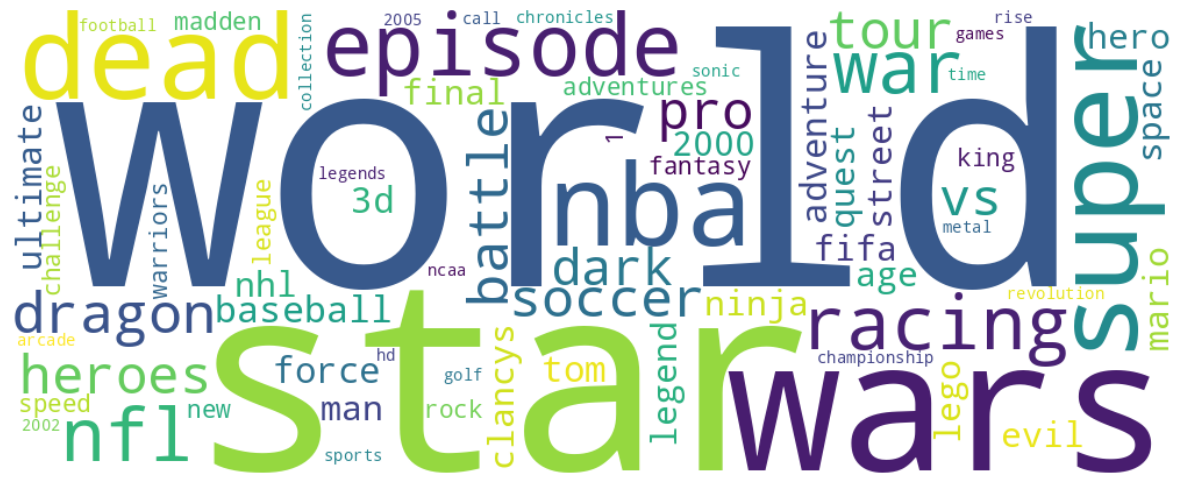

In [46]:
# @title ...
# Create a dictionary from the filtered_word_counts_df
word_freq = dict(zip(filtered_word_counts_df['Word'], filtered_word_counts_df['Count']))

wordcloud = WordCloud(width=1000, height=400, background_color='white', colormap='viridis').generate_from_frequencies(word_freq)


# Display the generated image:
plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()